# Energy Resolution Impact on Differential Cross Sections

This notebook visualises how TOF energy resolution broadens the differential
cross section at a given nominal energy. The top panel shows the elastic
cross-section (and $a_1$) curve inside the resolution window, coloured by
energy; the bottom panel overlays the individual angular distributions sampled
across that window, together with EXFOR experimental data.

**Workflow.** The notebook is split into sections. *Setup* reads the ENDF and
EXFOR files into memory once. To try a different nominal energy or window
width, edit the *Parameters* cell and re-run from there down — no file reload.

## 1 · Setup — run once

Loads the ENDF MF3/MF4 evaluation and the full EXFOR set into memory and
defines the helper functions. Nothing here depends on the nominal energy or
the window, so run this section only once per kernel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from numpy.polynomial.legendre import legval

import kika.exfor as exfor
from kika.exfor import read_all_exfor
from kika.plotting import PlotBuilder
from kika.endf.read_endf import read_mf3_mt, read_mf4_mt

# ── Static configuration (rarely changed) ────────────────────────────────────
TARGET = 'Fe56'
TARGET_NAT = 'Fe'
MT = 2
ENDF_PATH = '/soft_snc/lib/endf/jeff40/neutrons/26-Fe-56g.txt'
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'

FLIGHT_PATH_M = 27.037        # metres  (TOF flight path)
DELTA_T_NS = 10.0             # nanoseconds  (TOF timing resolution)
ENERGY_TOLERANCE = 0.02       # MeV  (EXFOR near-nominal selection)

COLORMAP_NAME = 'coolwarm'
NUM_ANGULAR_POINTS = 200
N_ENERGY_SAMPLES = 100

NEUTRON_MASS_MEV = 939.565378
C_M_NS = 0.299792458          # speed of light (m/ns)

exfor.configure(db_path=EXFOR_DB_PATH)

In [2]:
# ══ LOAD ONCE — expensive file I/O ═══════════════════════════════════════════
# Reads the ENDF MF3/MF4 evaluation and the full EXFOR set into memory. Nothing
# here depends on the nominal energy or the window, so run it only once.
mf3 = read_mf3_mt(ENDF_PATH, MT)   # elastic cross section sigma_el(E)
mf4 = read_mf4_mt(ENDF_PATH, MT)   # Legendre coefficients a_l(E)
print(f'MF4 frame: {mf4.frame}')

# Full native grids (MeV), kept in memory for fast windowing later
E_xs_all = np.asarray(mf3.energies, dtype=float) / 1e6
xs_all   = np.asarray(mf3.cross_sections, dtype=float)
LE_all   = np.asarray(mf4.legendre_energies, dtype=float) / 1e6

# Full Legendre coefficient table on every MF4 node (one pass over the file data)
_raw = [np.asarray(mf4.get_legendre_coefficients(e * 1e6), dtype=float) for e in LE_all]
L_MAX = max(len(c) for c in _raw)
COEFS_all = np.array([np.concatenate([c, np.zeros(L_MAX - len(c))]) for c in _raw])
print(f'MF3 nodes: {E_xs_all.size},  MF4 nodes: {LE_all.size},  L_MAX = {L_MAX}')

# Full EXFOR set for the target(s), loaded once; filtered per-energy later
_fe56 = read_all_exfor(target=TARGET, mt=MT, group_by_energy=False)
_fenat = read_all_exfor(target=TARGET_NAT, mt=MT, group_by_energy=False)
loaded_experiments = list(_fe56.values()) + list(_fenat.values())
print(f'EXFOR experiments loaded: {len(loaded_experiments)}')

MF4 frame: CM
MF3 nodes: 15048,  MF4 nodes: 3960,  L_MAX = 32
EXFOR experiments loaded: 119


In [28]:
# ── Static helper functions (depend only on the loaded evaluation) ───────────
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*']
tab_colors = plt.cm.tab10.colors

# Colours for the two window-average overlays
PLAIN_AVG_COLOR = '#DE8F05'      # green  — uniform (flat) average
GAUSS_AVG_COLOR = '#029E73'      # orange — Gaussian resolution-kernel average


def sigma_el(e_mev):
    """Elastic cross section (b) at e_mev, on the native MF3 grid."""
    return float(mf3.get_cross_section(e_mev * 1e6))


def legendre_a(e_mev):
    """Legendre coefficients [a1..aL] at e_mev, interpolated over the full MF4 grid."""
    return np.array([np.interp(e_mev, LE_all, COEFS_all[:, k]) for k in range(L_MAX)])


def dsigma_dOmega(mu, a_l, sigma):
    """Differential elastic cross section (b/sr) from a_l = [a1..aL] (a0 = 1) and sigma_el (b).

    d(sigma)/d(Omega) = sigma / (4 pi) * [1 + sum_l (2l+1) a_l P_l(mu)].
    Reconstructing from all orders means the whole shape moves with energy, not a1 alone.
    """
    a_l = np.asarray(a_l, dtype=float)
    coeffs = np.concatenate(([1.0], (2 * np.arange(1, len(a_l) + 1) + 1) * a_l))
    return sigma / (4 * np.pi) * legval(mu, coeffs)


def heatmap_line(ax, e_mev, y, linestyle='solid', lw=2.0, show_nodes=True, node_size=16):
    """Draw y(E) as a line color-coded by energy (heatmap).

    With show_nodes=True, a marker is placed at every stored ENDF grid point
    (the actual evaluation nodes: MF3 for sigma_el, MF4 for a_l), so the true
    grid density is visible instead of being hidden by the connecting line.
    Uses the module-level `cmap` / `e_norm_kev` set in the Derived section.
    """
    e_kev = np.asarray(e_mev, dtype=float) * 1e3
    pts = np.column_stack([e_kev, y]).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap=cmap, norm=e_norm_kev, linestyles=linestyle)
    lc.set_array(e_kev[:-1])
    lc.set_linewidth(lw)
    ax.add_collection(lc)
    if show_nodes:
        ax.scatter(e_kev, y, c=e_kev, cmap=cmap, norm=e_norm_kev,
                   s=node_size, zorder=3, edgecolors='none')
    ax.autoscale()
    return lc


def draw_window_averages(ax, mode):
    """Overlay the plain and/or Gaussian window-average curves for a given mode.

    Which curves appear is controlled by SHOW_PLAIN_AVERAGE / SHOW_GAUSSIAN_AVERAGE.
    """
    if SHOW_PLAIN_AVERAGE:
        ax.plot(mu_grid, avg_dsigma[mode], color=PLAIN_AVG_COLOR, lw=2.0,
                label=f'Window average ({N_SIGMA}$\\sigma$, plain)')
    if SHOW_GAUSSIAN_AVERAGE:
        ax.plot(mu_grid, avg_dsigma_gauss[mode], color=GAUSS_AVG_COLOR, lw=2.0,
                label=f'Window average ({N_SIGMA}$\\sigma$, Gaussian)')


def draw_fan(ax, mode):
    """Fan of d(sigma)/d(Omega) across the window for a given decomposition mode.

      norm  -> normalization varies (per-energy sigma_el), shape fixed to nominal
      shape -> shape varies (per-energy a_l, all orders), normalization fixed
      both  -> the physical distribution at each energy (real shape x real norm)
    """
    for e_sample in sample_energies:
        xs_e = sigma_el(e_sample)
        if xs_e <= 0:
            continue
        if mode == 'norm':          # vary normalization, fixed nominal shape
            a_l, s = a_nom, xs_e
        elif mode == 'shape':       # vary the full shape (all orders), fixed normalization
            a_l, s = legendre_a(e_sample), xs_nom
        else:                       # vary both
            a_l, s = legendre_a(e_sample), xs_e
        ax.plot(mu_grid, dsigma_dOmega(mu_grid, a_l, s),
                color=cmap(norm(e_sample)), alpha=0.4, lw=0.8)
    ax.plot(mu_grid, nominal_dsigma, color='black', ls='--', lw=1.5,
            label=f'Nominal ({NOMINAL_ENERGY_MEV} MeV)')
    draw_window_averages(ax, mode)
    for idx, exp in enumerate(all_experiments):
        plot_data = exp.to_plot_data(
            energy=NOMINAL_ENERGY_MEV, tolerance=ENERGY_TOLERANCE, frame='CM',
            angle_unit='cos', cross_section_unit='b/sr', uncertainty=True,
            include_natural_tag=True, marker=markers[idx % len(markers)],
            color=tab_colors[idx % len(tab_colors)], markersize=5, capsize=3, alpha=0.8,
        )
        if plot_data is not None:
            builder = PlotBuilder(ax=ax)
            builder.add_data(plot_data)
            builder.build()
    ax.set_xlim(-1, 1)
    ax.set_ylim(0.01, 3)
    ax.set_yscale('log')
    ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=13)
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=13)
    ax.tick_params(axis='both', which='both', labelsize=12)
    ax.legend(loc='best', fontsize=10)

## 2 · Parameters — tweak and re-run from here

Change the nominal energy or the window width below, then run this cell and the
rest of the notebook. No file reload is needed — the Setup section above stays
in memory.

In [39]:
# ══ TWEAK ME ═════════════════════════════════════════════════════════════════
NOMINAL_ENERGY_MEV = 1.40    # nominal (central) neutron energy, MeV
N_SIGMA = 3.0                # resolution window half-width, in units of sigma_E

# Which window-average curves to overlay on the angular-distribution panels.
# The plain average weights every energy in the window equally; the Gaussian
# average weights each energy by the TOF resolution kernel N(nominal, sigma_E).
SHOW_PLAIN_AVERAGE = False        # uniform (flat) average over the window
SHOW_GAUSSIAN_AVERAGE = True     # resolution-kernel (Gaussian) weighted average

In [40]:
# ── Derived from the parameters above (cheap to recompute; no file I/O) ───────
mu_grid = np.linspace(-1.0, 1.0, NUM_ANGULAR_POINTS)

# Energy resolution (same formula as scripts/tof_parameters.py:202)
velocity_m_ns = C_M_NS * np.sqrt(2.0 * NOMINAL_ENERGY_MEV / NEUTRON_MASS_MEV)
flight_time_ns = FLIGHT_PATH_M / velocity_m_ns
sigma_E_mev = NOMINAL_ENERGY_MEV * 2.0 * (DELTA_T_NS / flight_time_ns)
E_low = NOMINAL_ENERGY_MEV - N_SIGMA * sigma_E_mev
E_high = NOMINAL_ENERGY_MEV + N_SIGMA * sigma_E_mev
sample_energies = np.linspace(E_low, E_high, N_ENERGY_SAMPLES)
print(f'σ_E = {sigma_E_mev*1e3:.2f} keV')
print(f'Energy window: [{E_low:.4f}, {E_high:.4f}] MeV  ({N_SIGMA}σ)')

# Colour scale for the energy heatmaps (depends on the window)
cmap = plt.get_cmap(COLORMAP_NAME)
norm = mcolors.Normalize(vmin=E_low, vmax=E_high)
e_norm_kev = mcolors.Normalize(vmin=E_low * 1e3, vmax=E_high * 1e3)

# Native-grid slices inside the window (top panels), from the pre-loaded arrays
xs_mask = (E_xs_all >= E_low) & (E_xs_all <= E_high)
E_xs_win, xs_win = E_xs_all[xs_mask], xs_all[xs_mask]
le_mask = (LE_all >= E_low) & (LE_all <= E_high)
LE_win = LE_all[le_mask]
a1_win = COEFS_all[le_mask, 0]     # raw MF4 a1 node values inside the window

# Nominal shape and its differential cross section
a_nom = legendre_a(NOMINAL_ENERGY_MEV)
xs_nom = sigma_el(NOMINAL_ENERGY_MEV)
nominal_dsigma = dsigma_dOmega(mu_grid, a_nom, xs_nom)
n_orders_nom = len(mf4.get_legendre_coefficients(NOMINAL_ENERGY_MEV * 1e6))  # local, not L_MAX
print(f'Nominal: sigma_el = {xs_nom:.4f} b, a1 = {a_nom[0]:.4f}, '
      f'{n_orders_nom} Legendre orders at {NOMINAL_ENERGY_MEV} MeV')
print(f'Window grid points -> MF3 (sigma_el): {xs_mask.sum()},  MF4 (a_l): {le_mask.sum()}')

# Per-energy samples of sigma_el and each Legendre order across the window
xs_samples = np.array([sigma_el(e) for e in sample_energies])
a_samples = np.array([legendre_a(e) for e in sample_energies])

# Plain (uniform) window average: every energy in the window weighted equally
xs_avg = xs_samples.mean()
a_avg = a_samples.mean(axis=0)
avg_dsigma = {
    'norm':  dsigma_dOmega(mu_grid, a_nom, xs_avg),   # avg normalization, nominal shape
    'shape': dsigma_dOmega(mu_grid, a_avg, xs_nom),   # avg shape, nominal normalization
    'both':  dsigma_dOmega(mu_grid, a_avg, xs_avg),   # avg shape and normalization
}

# Gaussian-kernel window average: each energy weighted by the TOF resolution
# response N(nominal, sigma_E), normalized over the sampled window.
gauss_w = np.exp(-0.5 * ((sample_energies - NOMINAL_ENERGY_MEV) / sigma_E_mev) ** 2)
gauss_w /= gauss_w.sum()
xs_avg_g = float(np.dot(gauss_w, xs_samples))
a_avg_g = gauss_w @ a_samples
avg_dsigma_gauss = {
    'norm':  dsigma_dOmega(mu_grid, a_nom, xs_avg_g),   # avg normalization, nominal shape
    'shape': dsigma_dOmega(mu_grid, a_avg_g, xs_nom),   # avg shape, nominal normalization
    'both':  dsigma_dOmega(mu_grid, a_avg_g, xs_avg_g), # avg shape and normalization
}
print(f'Window average ({N_SIGMA}σ), plain:    sigma_el = {xs_avg:.4f} b, a1 = {a_avg[0]:.4f}')
print(f'Window average ({N_SIGMA}σ), Gaussian: sigma_el = {xs_avg_g:.4f} b, a1 = {a_avg_g[0]:.4f}')

# EXFOR experiments near the nominal energy (filter the pre-loaded set — cheap)
all_experiments = [
    exp for exp in loaded_experiments
    if np.any(np.abs(exp.energies(unit='MeV') - NOMINAL_ENERGY_MEV) <= ENERGY_TOLERANCE)
]
print(f'EXFOR experiments near {NOMINAL_ENERGY_MEV} MeV: {len(all_experiments)}')

σ_E = 16.95 keV
Energy window: [1.3492, 1.4508] MeV  (3.0σ)
Nominal: sigma_el = 1.0922 b, a1 = 0.1056, 6 Legendre orders at 1.4 MeV
Window grid points -> MF3 (sigma_el): 659,  MF4 (a_l): 101
Window average (3.0σ), plain:    sigma_el = 2.1042 b, a1 = 0.1399
Window average (3.0σ), Gaussian: sigma_el = 1.9799 b, a1 = 0.1442
EXFOR experiments near 1.4 MeV: 3


## 3 · Figures

Re-run these after changing the parameters. The green line is the window-average
differential cross section; the top panels mark every stored ENDF grid point
(MF3 for $\sigma_{el}$, MF4 for $a_1$).

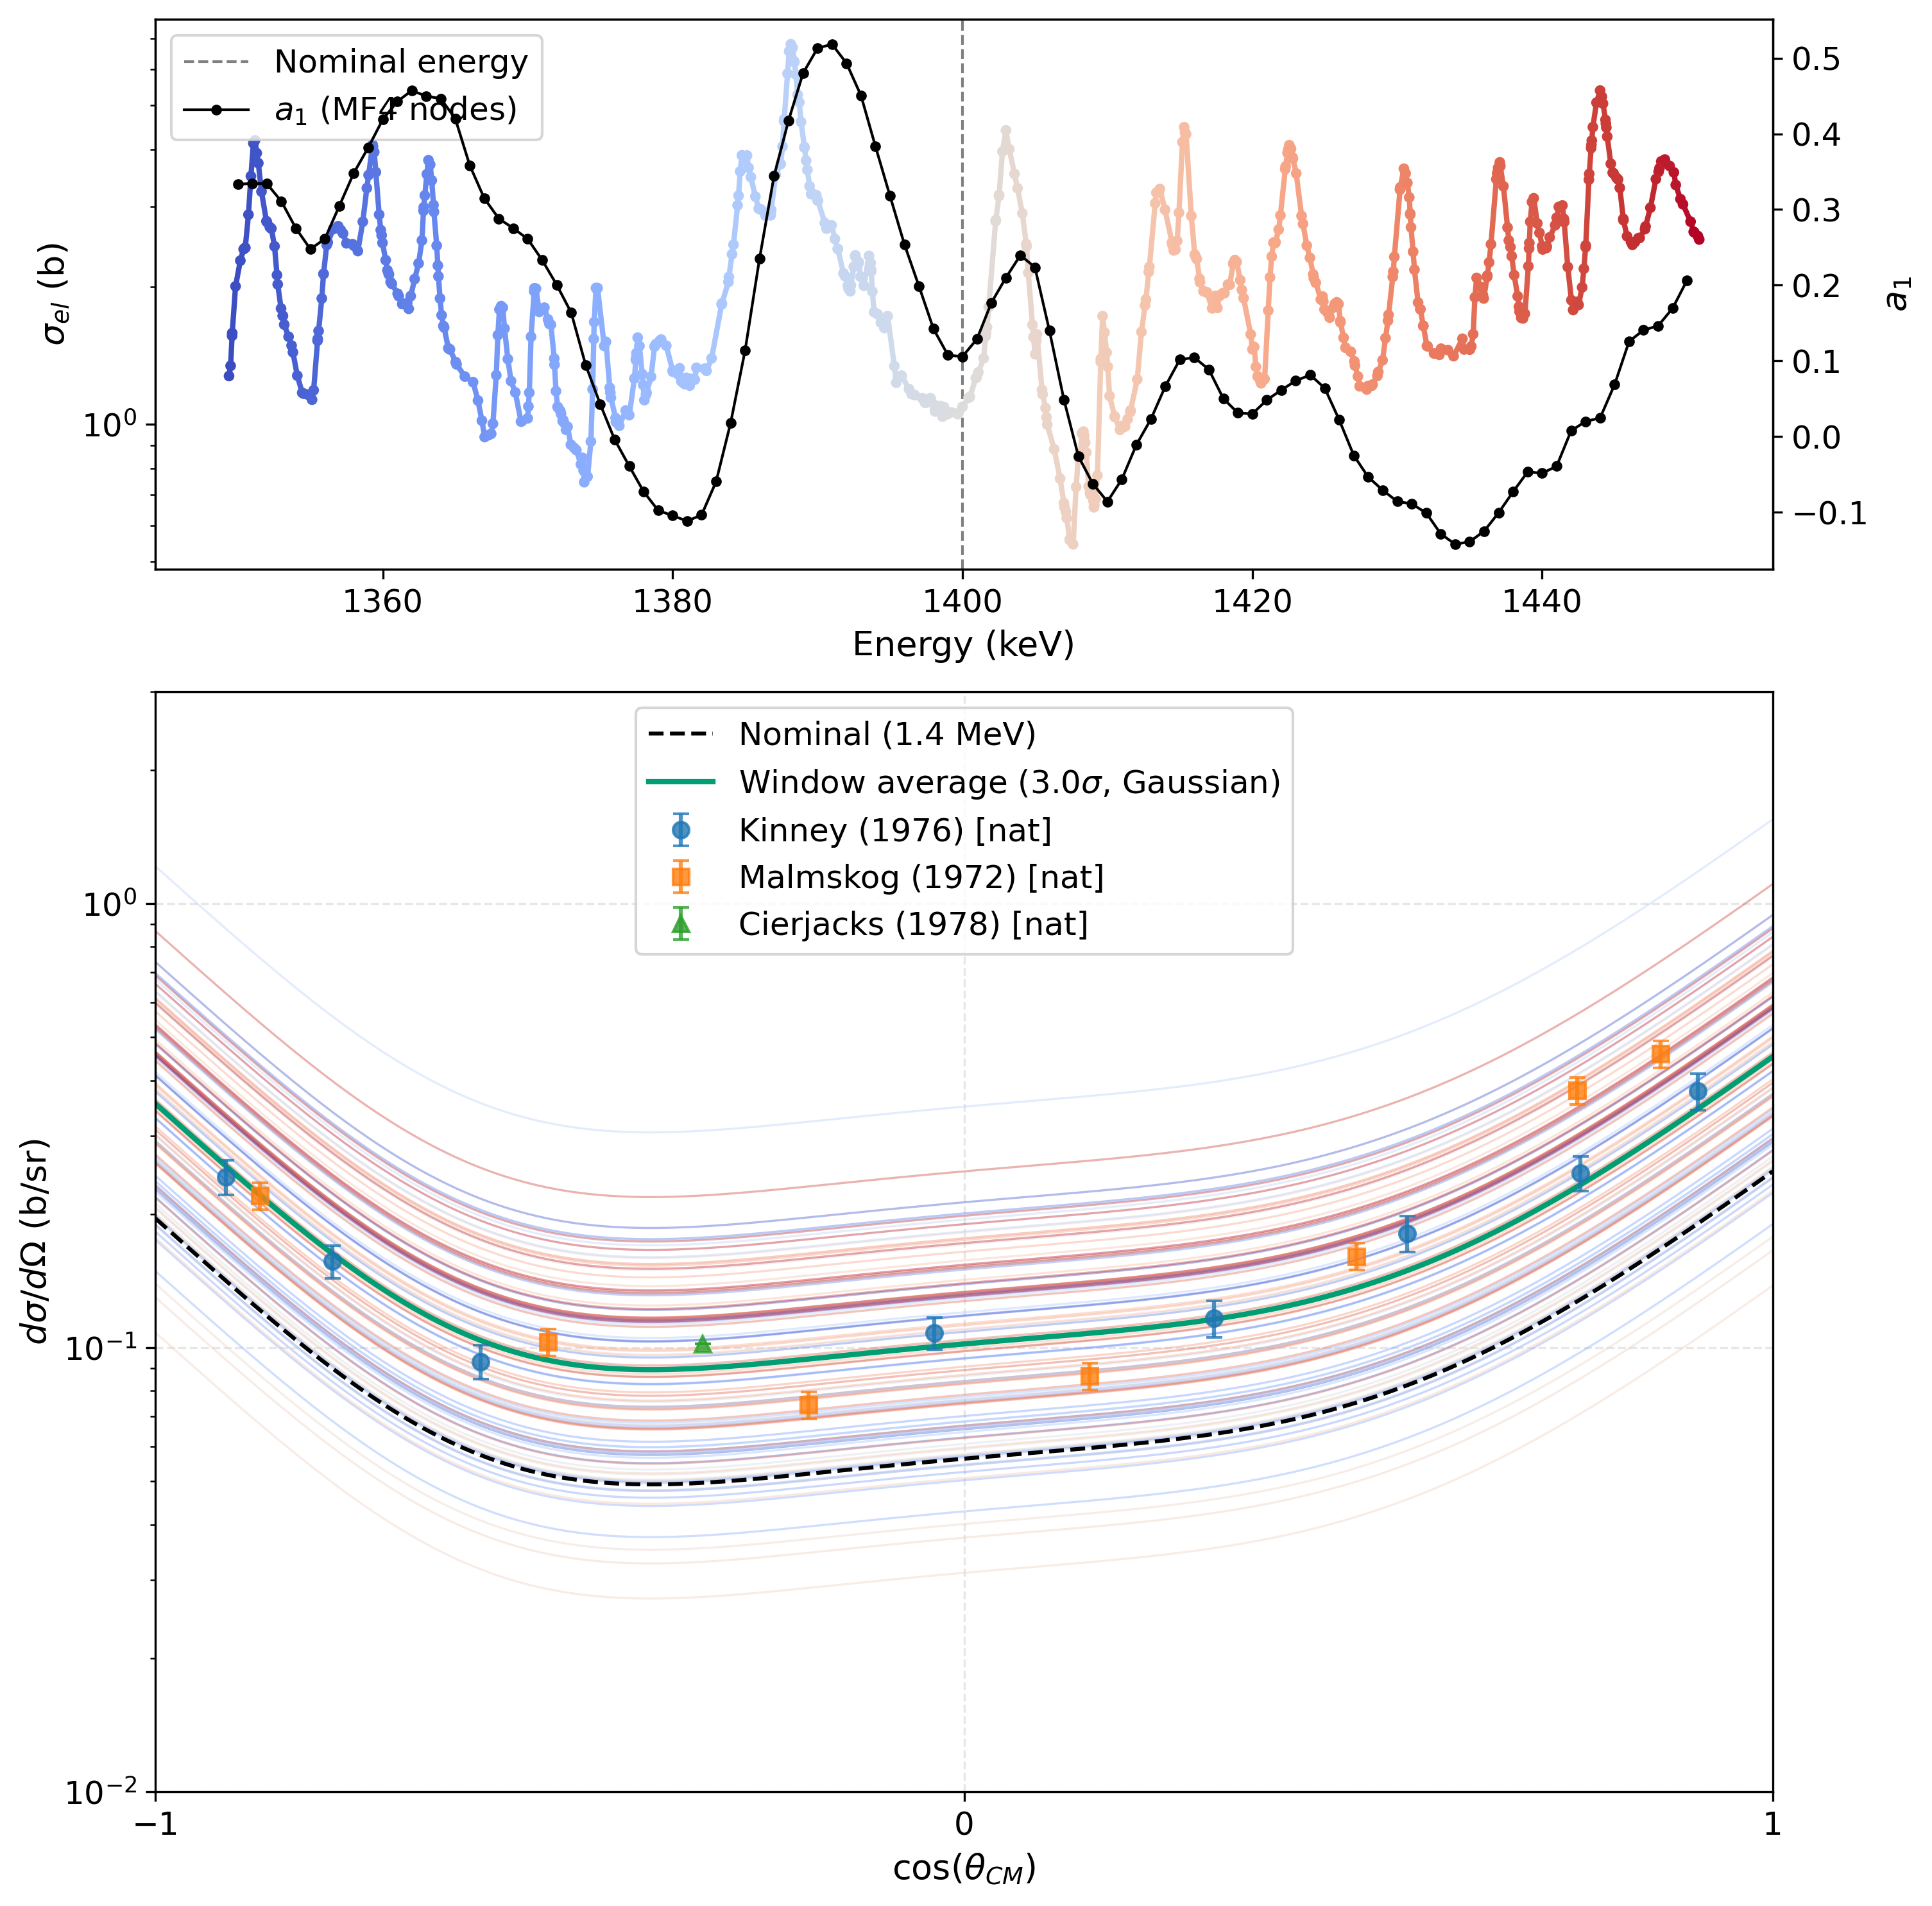

In [41]:
# ── Build figure: sigma_el + a1 (top), angular distributions across window (bottom) ──
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 2]}, dpi=300)

# ── Top: sigma_el coloured by energy (heatmap) ───────────────────────────────
e_kev = E_xs_win * 1e3
pts = np.column_stack([e_kev, xs_win]).reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap=cmap, norm=e_norm_kev)
lc.set_array(e_kev[:-1])
lc.set_linewidth(2)
ax_top.add_collection(lc)
ax_top.scatter(e_kev, xs_win, c=e_kev, cmap=cmap, norm=e_norm_kev,
               s=16, zorder=3, edgecolors='none')  # actual MF3 grid points
ax_top.autoscale()
ax_top.axvline(NOMINAL_ENERGY_MEV * 1e3, color='grey', ls='--', lw=1, label='Nominal energy')
ax_top.set_yscale('log')
ax_top.set_xlabel('Energy (keV)', fontsize=13)
ax_top.set_ylabel(r'$\sigma_{el}$ (b)', fontsize=13)
ax_top.tick_params(axis='both', which='both', labelsize=12)

# a1(E) on a secondary axis, straight from MF4
ax_top_a1 = ax_top.twinx()
ax_top_a1.plot(LE_win * 1e3, a1_win, color='black', lw=1.0,
               marker='o', ms=3, label=r'$a_1$ (MF4 nodes)')
ax_top_a1.set_ylabel(r'$a_1$', fontsize=13)
ax_top_a1.tick_params(axis='y', which='both', labelsize=12)
lines_l, labels_l = ax_top.get_legend_handles_labels()
lines_r, labels_r = ax_top_a1.get_legend_handles_labels()
ax_top.legend(lines_l + lines_r, labels_l + labels_r, loc='best', fontsize=12)

# ── Bottom: nominal shape scaled by the per-energy cross section (normalization only) ──
for e_sample in sample_energies:
    xs_e = sigma_el(e_sample)
    if xs_e <= 0:
        continue
    ax_bot.plot(mu_grid, dsigma_dOmega(mu_grid, a_nom, xs_e),
                color=cmap(norm(e_sample)), alpha=0.4, lw=0.8)
ax_bot.plot(mu_grid, nominal_dsigma, color='black', ls='--', lw=1.5,
            label=f'Nominal ({NOMINAL_ENERGY_MEV} MeV)')
draw_window_averages(ax_bot, 'norm')

for idx, exp in enumerate(all_experiments):
    plot_data = exp.to_plot_data(
        energy=NOMINAL_ENERGY_MEV, tolerance=ENERGY_TOLERANCE, frame='CM',
        angle_unit='cos', cross_section_unit='b/sr', uncertainty=True,
        include_natural_tag=True, marker=markers[idx % len(markers)],
        color=tab_colors[idx % len(tab_colors)], markersize=6, capsize=3, alpha=0.8,
    )
    if plot_data is not None:
        builder = PlotBuilder(ax=ax_bot)
        builder.add_data(plot_data)
        builder.build()

ax_bot.set_xlim(-1, 1)
ax_bot.set_ylim(0.01, 3)
ax_bot.set_yscale('log')
ax_bot.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=13)
ax_bot.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=13)
ax_bot.tick_params(axis='both', which='both', labelsize=12)
ax_bot.legend(loc='best', fontsize=12)

plt.tight_layout()
plt.show()

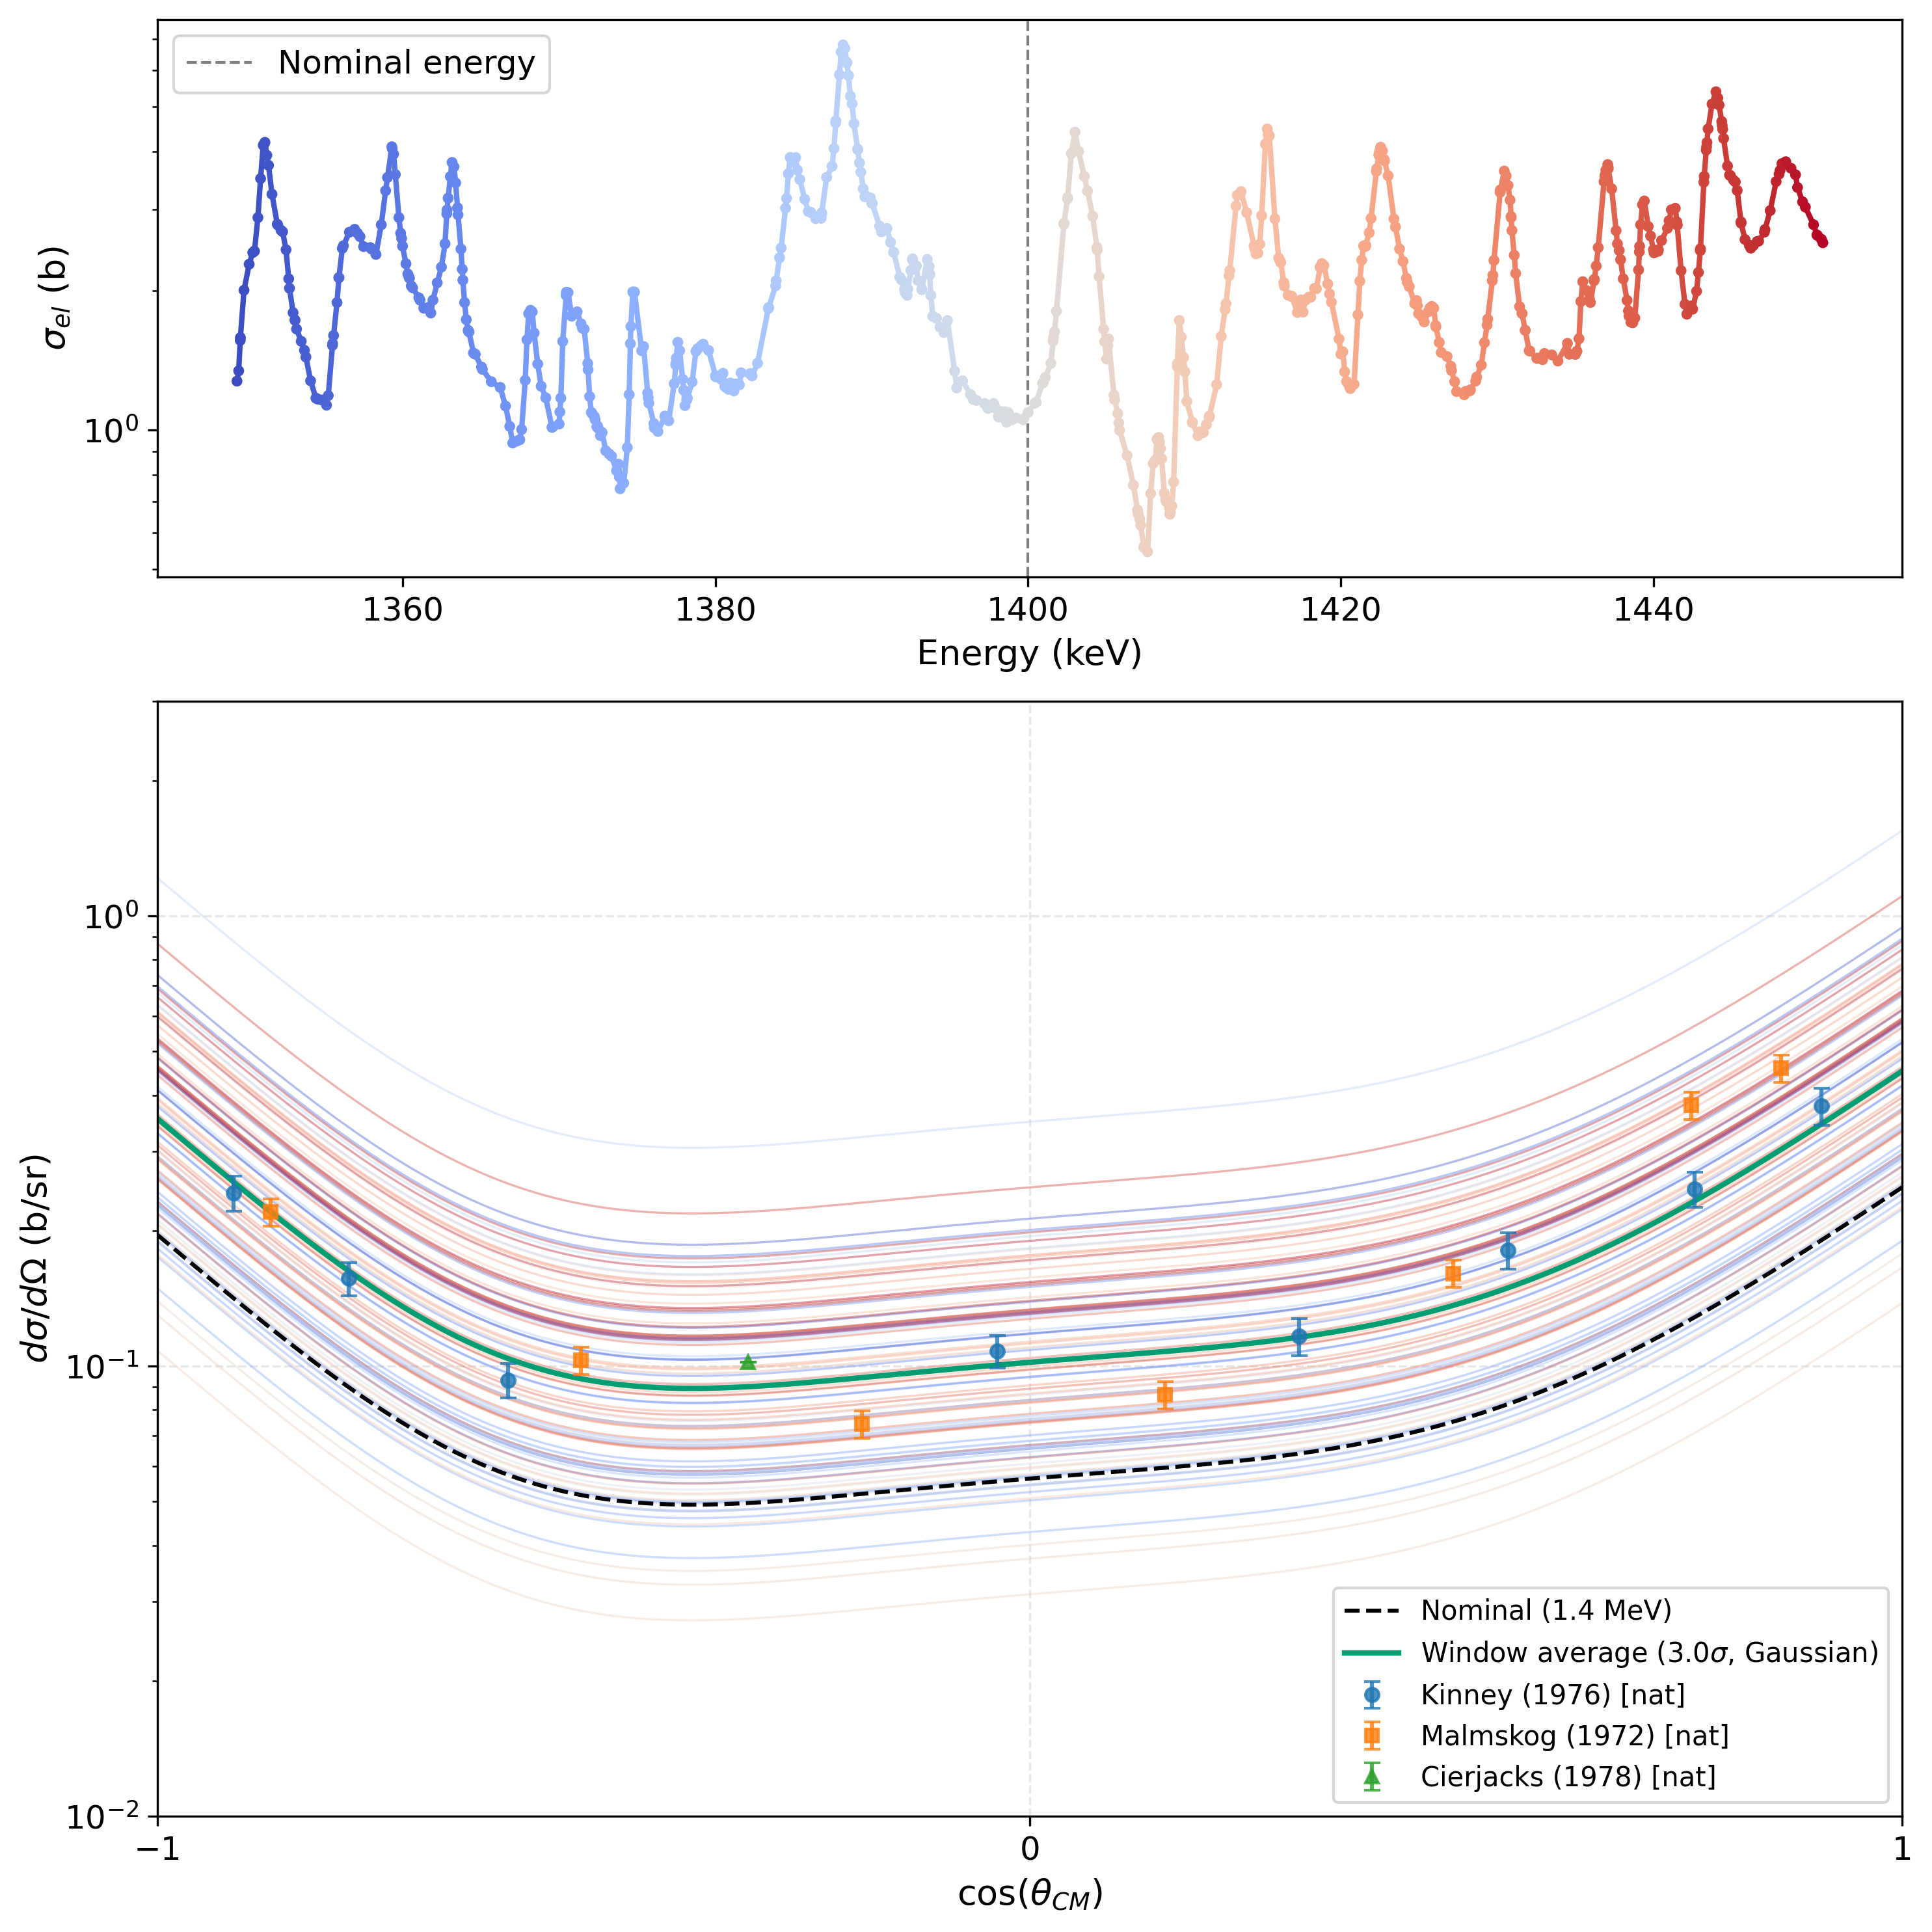

In [42]:
# ── Figure 1: normalization varies, shape fixed ──────────────────────────────
# Top: sigma_el(E) as an energy heatmap across the window.
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 2]}, dpi=300)

heatmap_line(ax_top, E_xs_win, xs_win)
ax_top.axvline(NOMINAL_ENERGY_MEV * 1e3, color='grey', ls='--', lw=1, label='Nominal energy')
ax_top.set_yscale('log')
ax_top.set_xlabel('Energy (keV)', fontsize=13)
ax_top.set_ylabel(r'$\sigma_{el}$ (b)', fontsize=13)
ax_top.tick_params(axis='both', which='both', labelsize=12)
ax_top.legend(loc='best', fontsize=12)

draw_fan(ax_bot, 'norm')
plt.tight_layout()
plt.show()

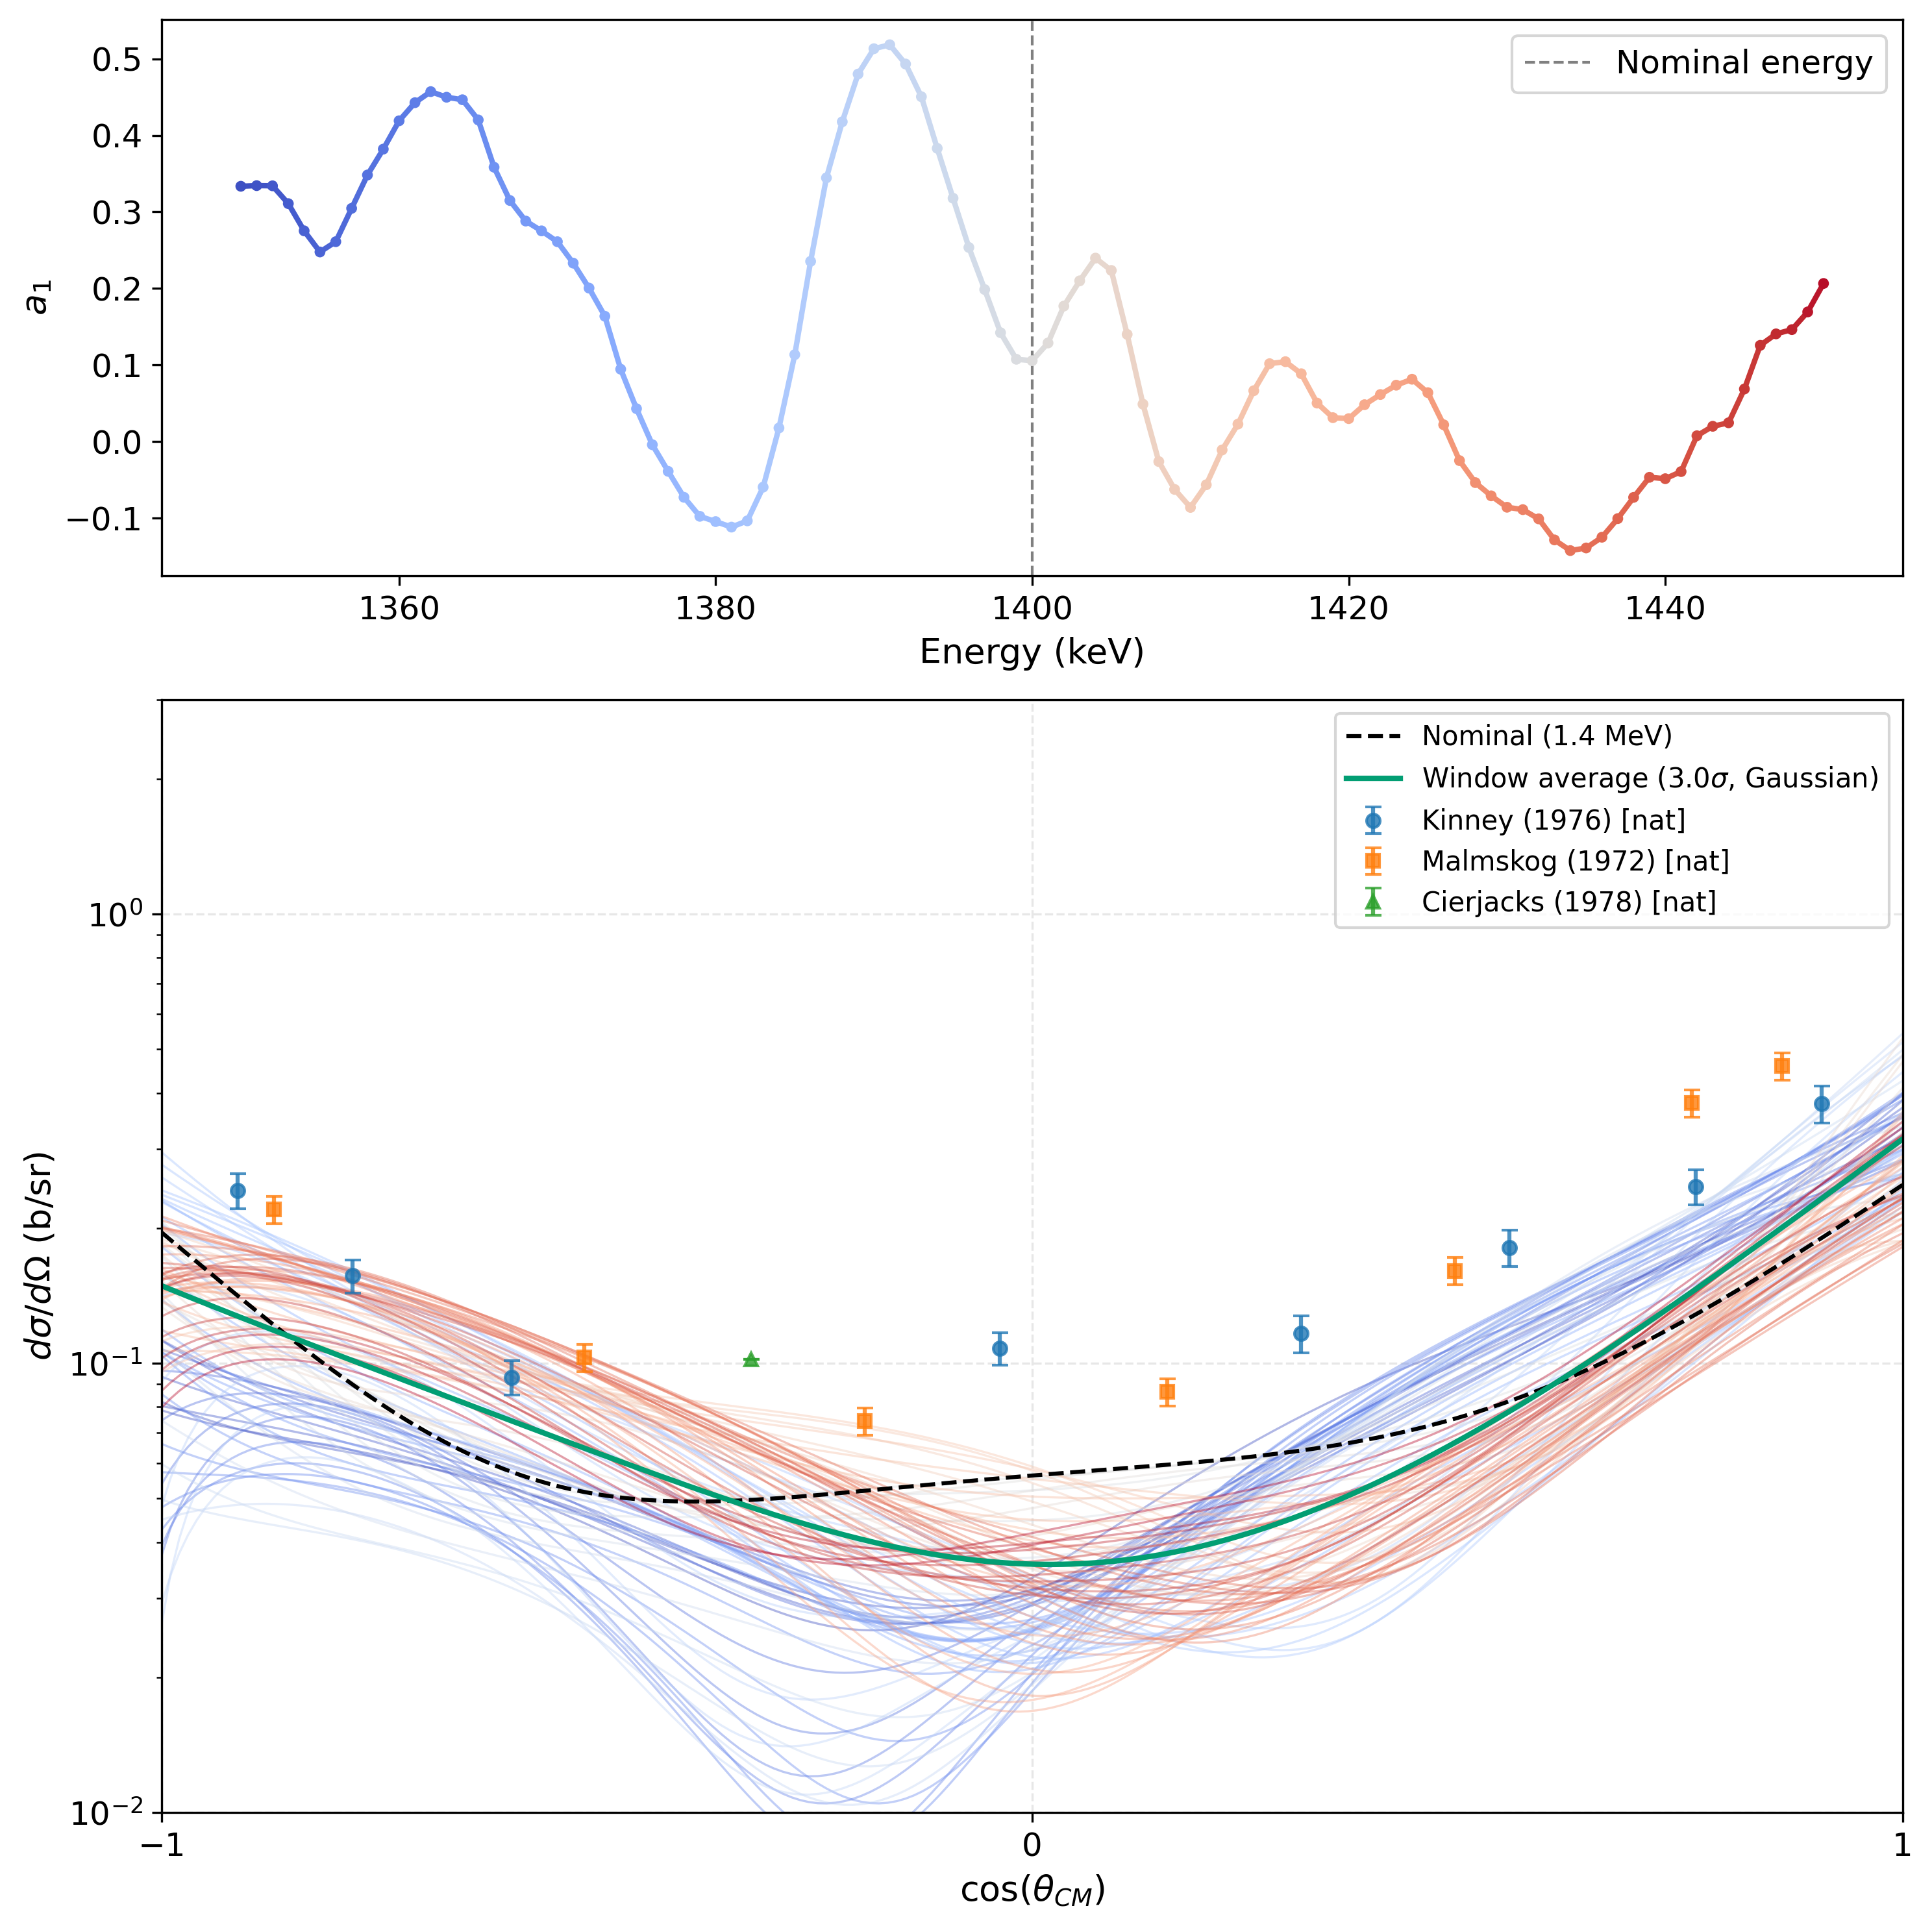

In [43]:
# ── Figure 2: shape varies, normalization fixed ──────────────────────────────
# Top: a1(E) as an energy heatmap; the fan below reconstructs all Legendre orders,
# so the whole angular shape moves with energy, not a1 alone.
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 2]}, dpi=300)

heatmap_line(ax_top, LE_win, a1_win)
ax_top.axvline(NOMINAL_ENERGY_MEV * 1e3, color='grey', ls='--', lw=1, label='Nominal energy')
ax_top.set_xlabel('Energy (keV)', fontsize=13)
ax_top.set_ylabel(r'$a_1$', fontsize=13)
ax_top.tick_params(axis='both', which='both', labelsize=12)
ax_top.legend(loc='best', fontsize=12)

draw_fan(ax_bot, 'shape')
plt.tight_layout()
plt.show()

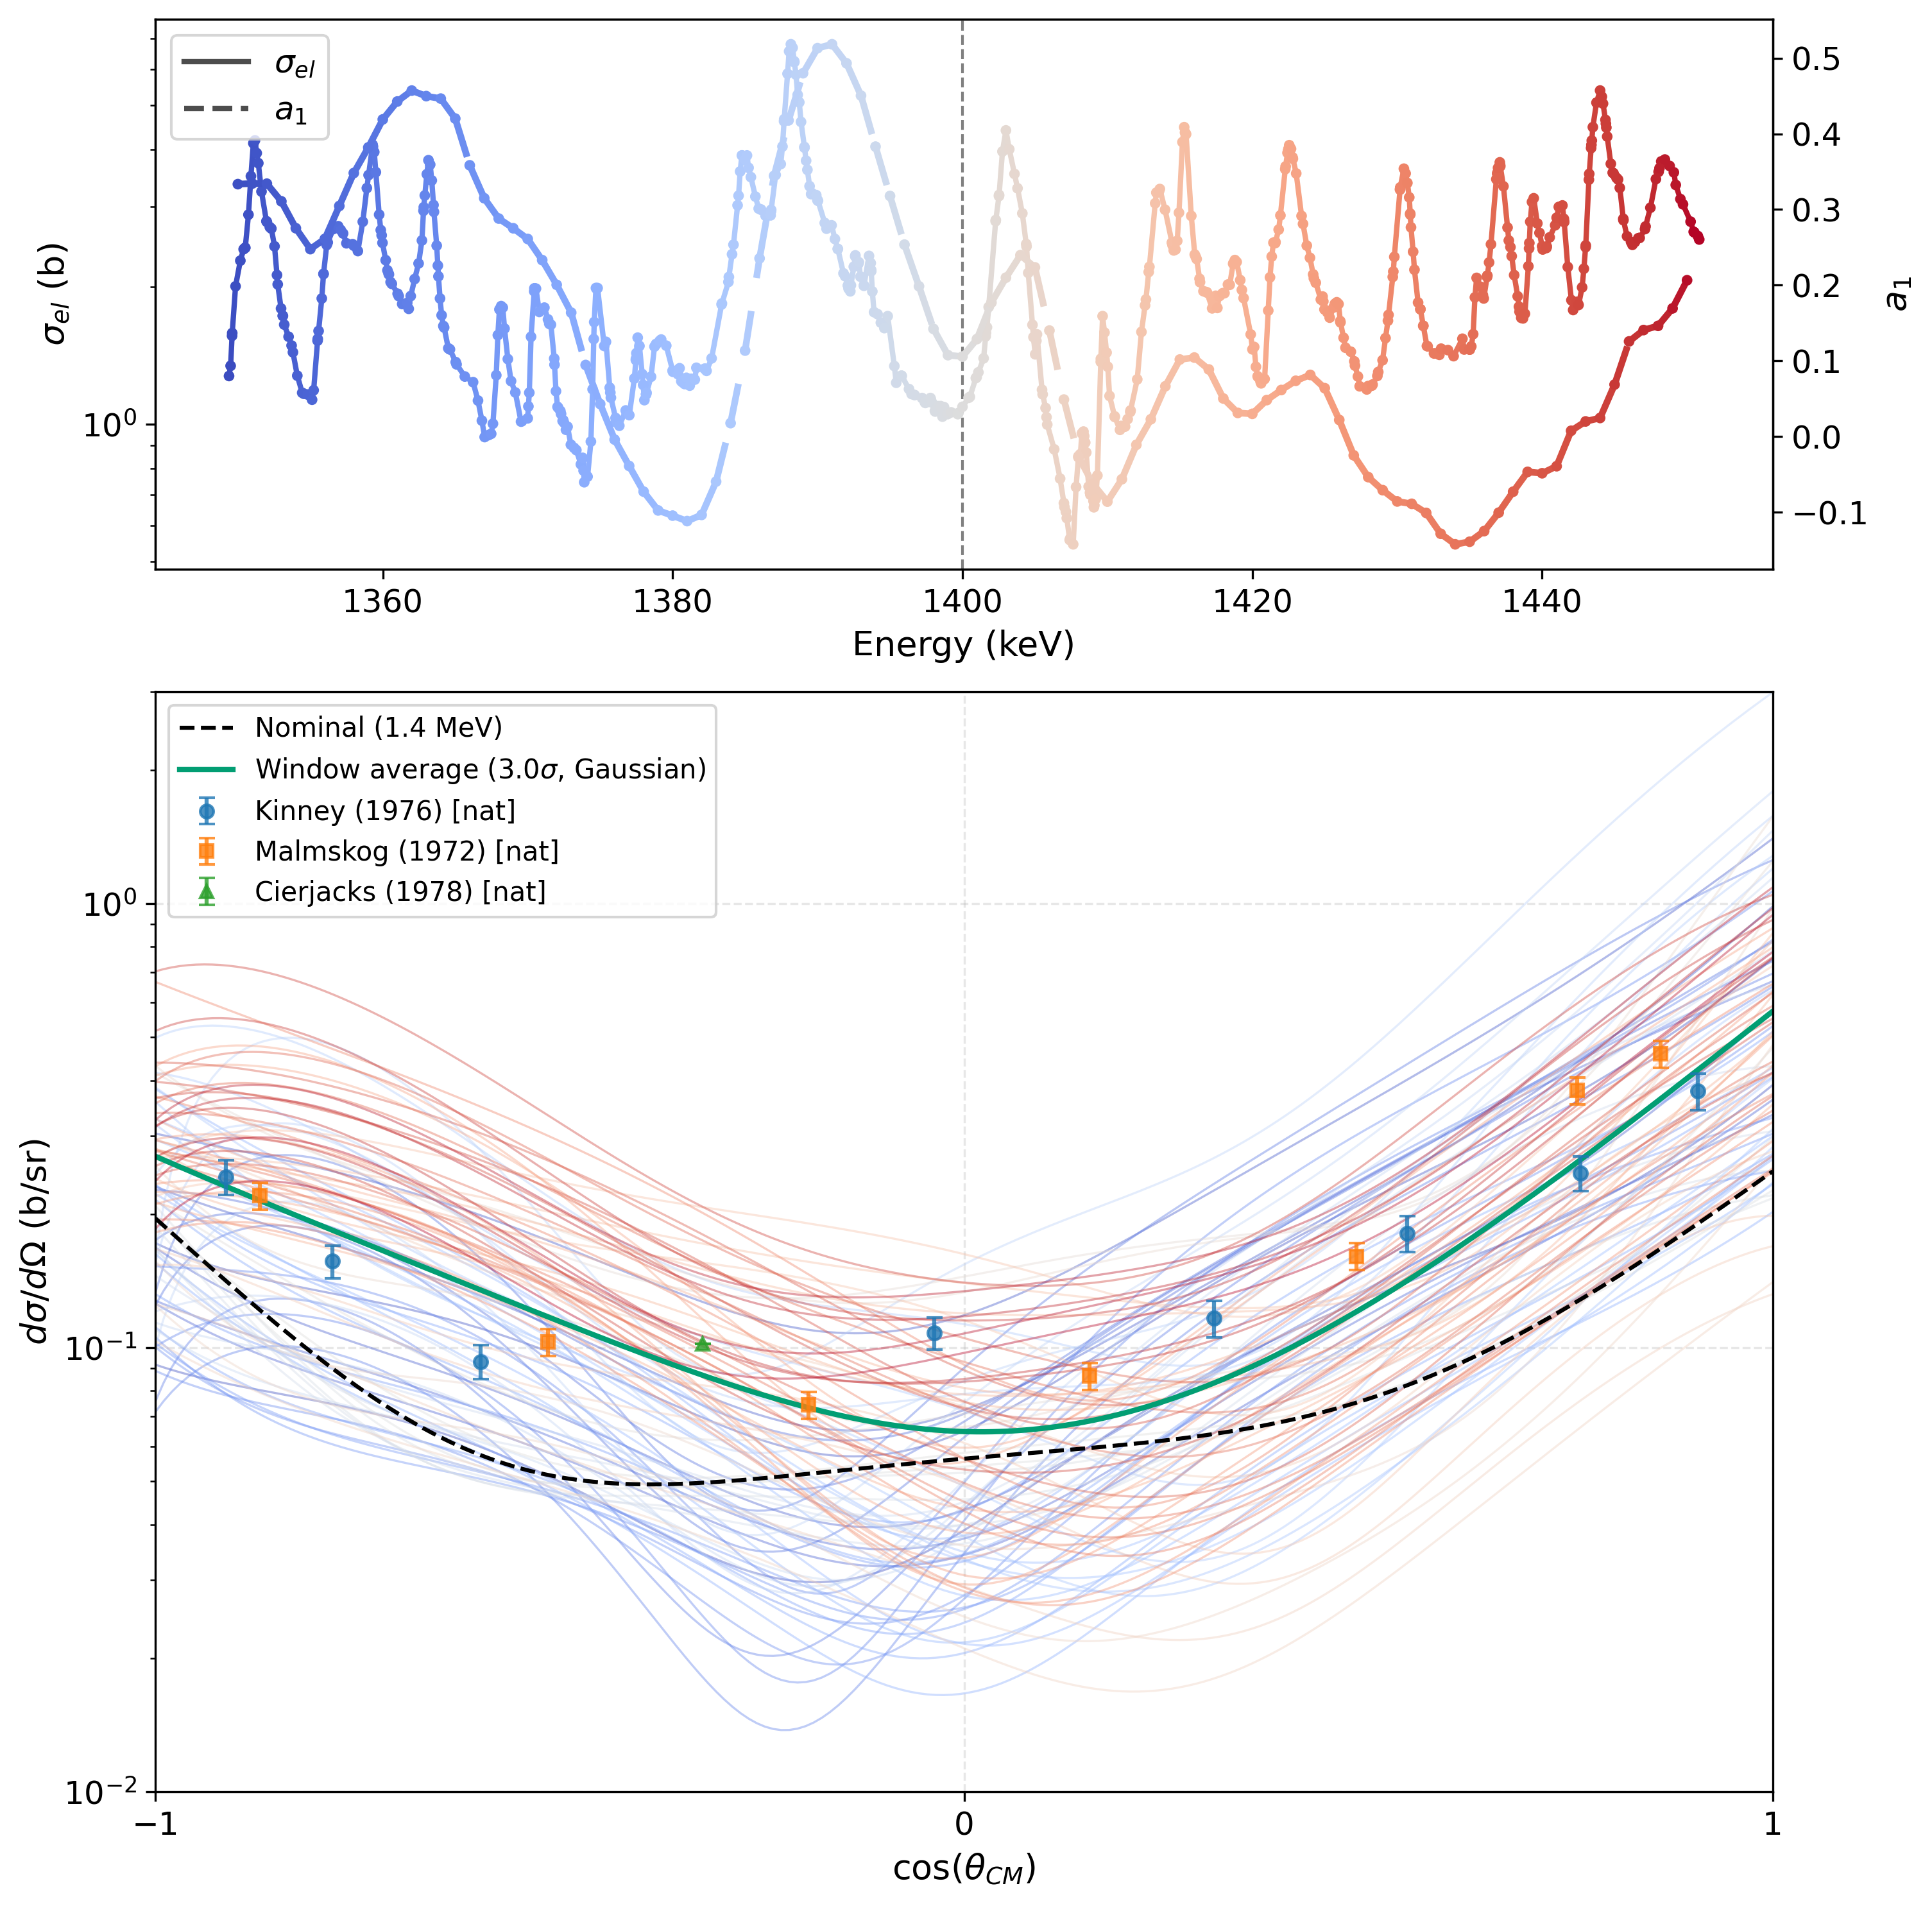

In [44]:
# ── Figure 3: shape and normalization vary together ──────────────────────────
# Top: sigma_el (solid) and a1 (dashed) both as energy heatmaps on twin axes.
# Both are shown on their full native ENDF grids (MF3 for sigma_el, MF4 for a1).
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 2]}, dpi=300)

heatmap_line(ax_top, E_xs_win, xs_win, linestyle='solid')
ax_top.set_yscale('log')
ax_top.axvline(NOMINAL_ENERGY_MEV * 1e3, color='grey', ls='--', lw=1)
ax_top.set_xlabel('Energy (keV)', fontsize=13)
ax_top.set_ylabel(r'$\sigma_{el}$ (b)', fontsize=13)
ax_top.tick_params(axis='both', which='both', labelsize=12)

ax_top_a1 = ax_top.twinx()
heatmap_line(ax_top_a1, LE_win, a1_win, linestyle=(0, (6, 5)), lw=2.5)  # full MF4 grid
ax_top_a1.set_ylabel(r'$a_1$', fontsize=13)
ax_top_a1.tick_params(axis='y', which='both', labelsize=12)

# Legend proxies: solid = sigma_el, dashed = a1 (both color-coded by energy)
ax_top.plot([], [], color='0.3', ls='-', lw=2, label=r'$\sigma_{el}$')
ax_top.plot([], [], color='0.3', ls='--', lw=2, label=r'$a_1$')
ax_top.legend(loc='best', fontsize=12)

draw_fan(ax_bot, 'both')
plt.tight_layout()
plt.show()